# **Credit Card Fraud Detaction -EDA , Feature Engineering & model Comparison**

In [22]:
# setup - imports
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import( precision_recall_curve, average_precision_score , roc_auc_score , classification_report , confusion_matrix , precision_score ,recall_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


In [23]:
#optimal models
try:
  import xgboost as xgb
except Exception as e:
  xgb = None
  print('XGBoost not available',e)
try:
  import lightgbm as lgb
except Exception as e:
  lgb = None
  print('LightGBM not available',e)
import joblib
print('setup complete')


setup complete


In [24]:
import os
import pandas as pd

# 1 Load data
DATA_PATH = 'creditcard.csv' #ensure file in the same dictionary
assert os.path.exists(DATA_PATH),f"Dataset not fount at {DATA_PATH}. please place creditcard.csv next to the notebook."
# The error "ParserError: Error tokenizing data. C error: Expected 31 fields in line 5966, saw 51"
# indicates that line 5966 in the creditcard.csv file has a different number of fields (51)
# than the expected number (31). This can happen due to malformed data, incorrect delimiters,
# or unescaped characters within fields.
# To handle this, we can tell pandas to skip lines that cause parsing errors.
# 'on_bad_lines' is available in pandas 1.3.0 and later.
df=pd.read_csv(DATA_PATH, on_bad_lines='skip')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.0727811733098497,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018306777944153,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.26615071205963,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775248033138,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.34016307473609,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998153469754,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226008082898,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300452035545,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877736754848451,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.00943069713232919,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


Rows, Columns: (328921, 31)
Time      float64
V1         object
V2         object
V3        float64
V4        float64
V5        float64
V6         object
V7        float64
V8         object
V9         object
V10        object
V11       float64
V12       float64
V13        object
V14       float64
V15        object
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21        object
V22       float64
V23        object
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class     float64
dtype: object

Missing values (top20): 
 Class     74
Amount    69
V28       61
V27       60
V26       58
V25       50
V24       47
V23       46
V22       42
V21       40
V20       38
V19       36
V18       34
V17       29
V16       22
V15       19
V14       15
V13       13
V12       13
V11       11
dtype: int64

 Target distribution:
Class
0.0    328154
1.0       693
Name: count, dtype: int64
Fraud ratio: 0.00

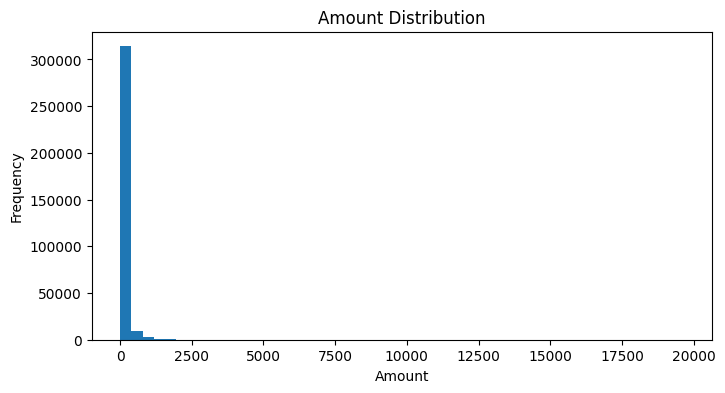

In [25]:
#2 Quick EDA
print('Rows, Columns:', df.shape)
print(df.dtypes)
print('\nMissing values (top20): \n', df.isnull().sum().sort_values(ascending=False).head(20))
target_col ='Class'
print('\n Target distribution:')
print(df[target_col].value_counts())
print('Fraud ratio:', df[target_col].mean())

#amount distribution
plt.figure(figsize=(8,4))
plt.hist(df['Amount'], bins=50)
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.title('Amount Distribution')
plt.show()

In [ ]:
# time-based overview ( the dataset's time column in seconds since first transaction)
if 'Time' in df.columns:
    df['Hour'] =(df['Time'] / 3600 % 24 )
    plt.figure(figsize=(10,4))
    df.groupby('Hour').size().plot(kind='bar')
    plt.title('Transaction by hour')
    plt.show()

# ***DATA - ANALYSIS***

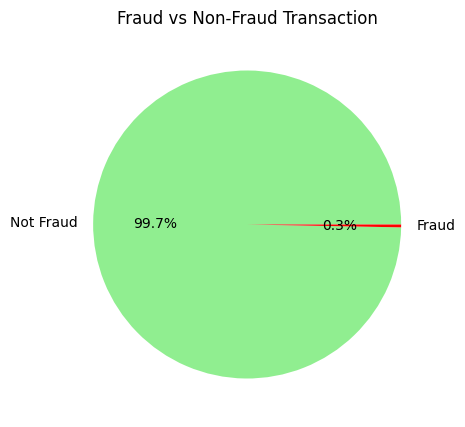

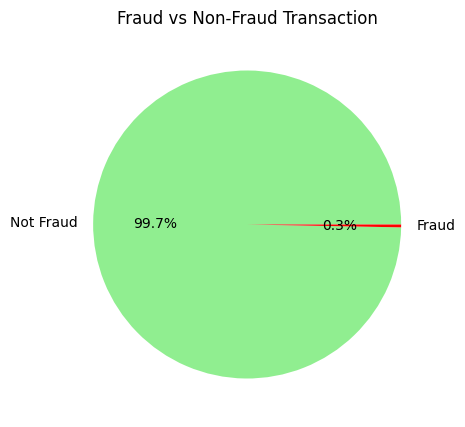

In [ ]:
# pie chart
plt.figure(figsize=(5,5))
plt.pie(df['Class'].value_counts(), labels=['Not Fraud', 'Fraud'], autopct='%1.1f%%', colors=['lightgreen' ,'red'])
plt.title('Fraud vs Non-Fraud Transaction')
plt.show()

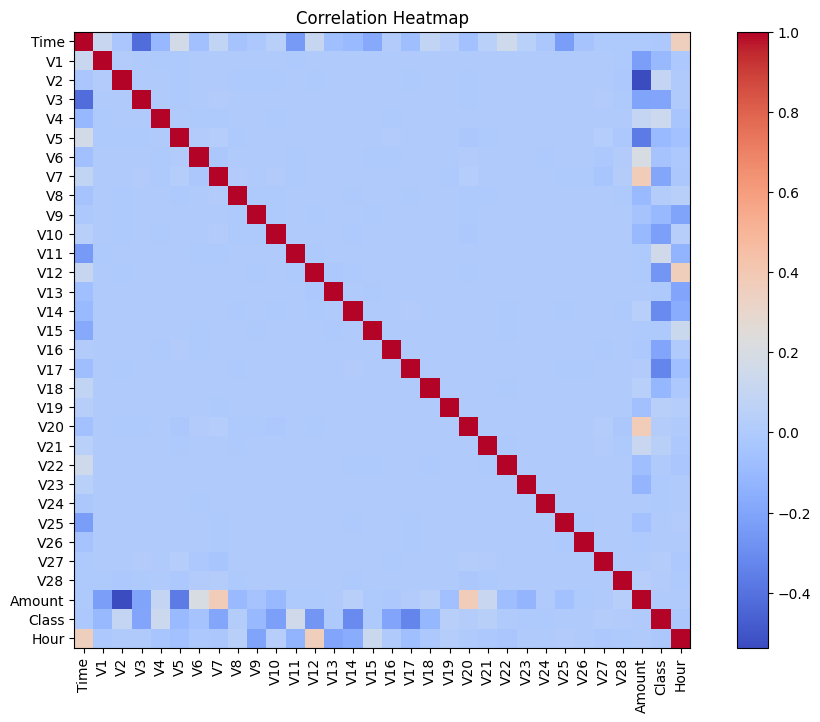

In [ ]:
## correlation Heatmap
plt.figure(figsize=(12,8))
corr=df.corr()
plt.imshow(corr, cmap='coolwarm' , interpolation ='nearest')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns , rotation= 90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Heatmap')
plt.show()

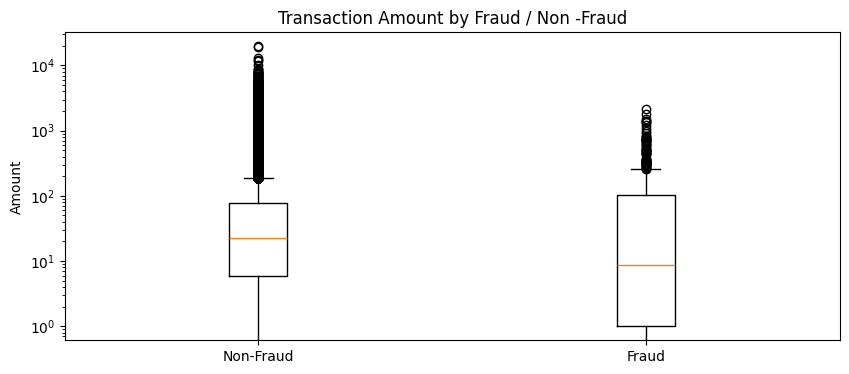

In [ ]:
# fraud vs non-fraud Amount
plt.figure(figsize=(10,4))
amount_nonfraud =df[df['Class']==0]['Amount']
amount_fraud= df[df['Class']==1]['Amount']
plt.boxplot([amount_nonfraud,amount_fraud], labels=['Non-Fraud','Fraud'])
plt.yscale('log') ## because amount are seeked
plt.ylabel('Amount')
plt.title('Transaction Amount by Fraud / Non -Fraud')
plt.show()

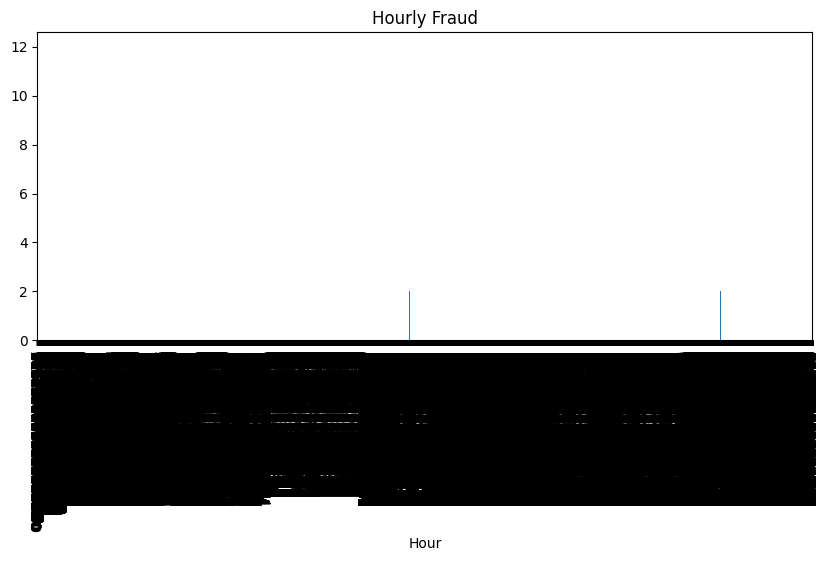

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import os

DATA_PATH = 'creditcard.csv'

if not os.path.exists(DATA_PATH):
    print(f"Error: The file '{DATA_PATH}' was not found.")
    print("Please make sure 'creditcard.csv' is uploaded to your Colab environment or mounted from Google Drive.")
else:
    df=pd.read_csv(DATA_PATH)
    df['Hour'] =(df['Time'] / 3600 % 24 )

    # Hourly fraud
    hourly=df.groupby('Hour')['Class'].sum()
    plt.figure(figsize=(10,4))
    hourly.plot(kind='bar')
    plt.title('Hourly Fraud')
    plt.show()

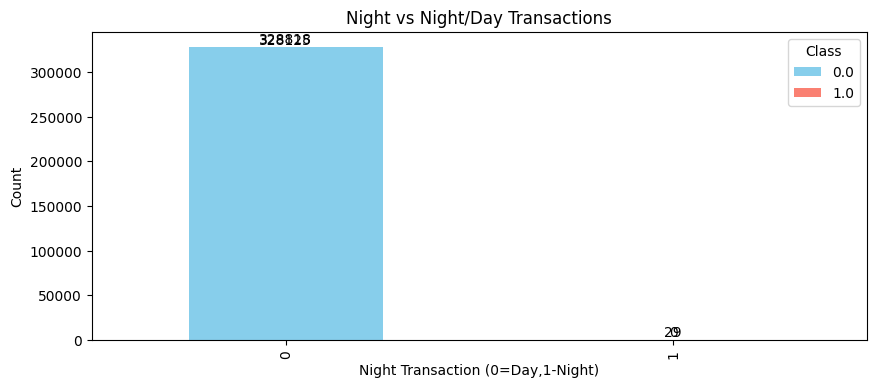

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

## night vs day fraud
# Ensure 'Hour' column exists
if 'Hour' not in df.columns:
    if 'Time' in df.columns:
        df['Hour'] = (df['Time'] / 3600 % 24).astype(int)
        print("Column 'Hour' created as it was not found in 'df'.")
    else:
        print("Error: 'Time' column not found in DataFrame 'df'. Cannot create 'Hour' column.")
        raise KeyError("'Time' column not found. Cannot compute 'Hour'.")

df['is_night'] = df['Hour'].isin([22,23,0,1,2,3,4,5]).astype(int)

night_fraud=df.groupby(['is_night','Class']).size().unstack(fill_value=0)
ax=night_fraud.plot(kind='bar', stacked=True,figsize=(10,4),color=['skyblue','salmon'])
plt.xlabel('Night Transaction (0=Day,1-Night)')
plt.ylabel('Count')
plt.title('Night vs Night/Day Transactions')
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [ ]:
## 3 .feature engineering (basic)
## we will create a few straight forward features that often help:
## -log_amount
#-amount_to_mean_ration (global_mean)
#is_high_amount(amount above 9 th percentile)

df_fe=df.copy()
df_fe['log_amount']=np.loglp(df_fe['Amount'])
global_mean=df_fe['Amount'].mean()
df_fe['amount_to_mean']=df_fe['Amount']/(global_mean + 1e-9)
p99=df_fe['Amount'].quantile(0.99)
df_fe['is_high_amount']=df_fe['Amount']>p99.astype(int)

#hour/night
if 'Hour' in df_fe.columns:
  df_fe['is night'] = df_fe['Hour'].isin([0,1,2,3,4,5,22,23]).astype(int)
else:
  df_fe['is_night'] =0

## drop the columns we dont want to feed directly (ti,e kept for refernce)
x=df_fe.drop(columns=[target_col])
y=df_fe['taregt_col'].values

print('Feature engineering complete .X shape',x.shape)


In [ ]:
# train test split(staisfied)
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,satisfy=y,random_state=42)
print('Train:' X_train.shape,'Test:',X_test.shape)

#scaling numeric value
numeric_feature=X_train.select_dtypes(include=[np.number]).columns.tolist()
scaler=RobustScaler()
scaler.fit(X_train[numeric_features])

def prep(x_df):
  Xc = X_df.copy()
  Xc[numeric_feature] = scaler.transform(Xc[numeric_feature])
  #drop time column to avoid leakage of absolute timestamp ; keep hour if present
  if 'Time' in Xc.columns:
    Xc=Xc.drop(columns=['Time'])
  return Xc

X_train_proc= prep(X_train)
X_test_proc= prep(X_test)
print('Processed data shapes:', X_train_proc.shape, X_test_proc.shape)




In [ ]:
## 5 evalution utilities
def evaluate_model(model,X_test,y_test,thresh=0.5,show_pr_curve=True):
  #obtain probabilites or scores
  if hasattr(model,'predict_proba'):
    y_score=model.predict_proba(X_test)[:,1]
  elif hasattr(model,'decision_function'):
    s= model.decision_function(X_test)
    y_score=(s-s.min())/(s.max()-s.min()+1e-9)
  else:
    y_score= model.predict(X_test)
  y_pred = (y_score >= thresh).astype(int)
  print('Classification report (threshold={}):'.format(thresh))
  print(classification_report(y_test,y_pred,digits=4))
  ap=average_precision_score(y_test,y_scores)
  roc=roc_auc_score(y_test,y_scores)
  cm=confusion_matrix(y_test,y_pred)
  print('Confusion matrix:\n',cm)
  print('ROC AUC =',roc)
  print('Average Precision (AP):',ap)
  if show_pr_curve:
    precision,recall,thresholds=precision_recall_curve(y_test,y_score)
    plt.figure(figsize=(8,4))
    plt.plot(recall,precision)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('f'PR curve(AP=(ap:.4f))')
    plt.show()
  return {'AP':ap,'ROC':roc,'CM':cm,'scores':y_score}

In [ ]:
## 6 train baeline model
trained_models = {}

#Logestic Regression
lr=LogisticRegression(max_iter=1000,class_weight='balanced',solver='saga')
lr.fit(X_train_proc,y_train)
trained_models['LogisticRegression']=lr
print('Trained LogisticRegression')

##random Forest
rf= RandomForestClassifier(n_estimators=100,class_weight='balanced',n_jobs=-1)
rf.fit(X_train_proc,y_train)
trained_models['RandomForest']=rf
print('Trained Random Forest')

#XGboost
xgb_clf=xgb.XGBClassifier(use_label_encoder=False,,eval_metric='logloss',scale_pos_weight=(np.sum(y_train==0)/np.sum(y_train==1)))
xgb_clf.fit(X_train_proc,y_train)
trained_models['XGBoost']=xgb_clf
print('Trained XGBoost')

In [ ]:
## Evaluate all trained models
results=[]
for name,model in trained_models.items():
  print('\n===Model:',name,'===')
  res = evaluate_model(model,X_test_proc,y_test)
  result.append({'model': name , 'AP': res['AP'],'ROC':res['ROC']})
 res_df=pd.DataFrame(results).sort_values('AP',ascending=False)
res_df


In [ ]:
## 8 threshold tuning (example using best available model) and flag extraction
# choose model with highest AP from res_df
best_model_name=res_df.iloc[0]['model']
best_model=trained_models[best_model_name]
print('Best model:',best_model_name)

#predict scores on test set and compute best threshold by f1 on test (for demonstration)
if hasattr(best_model,'predict_proba'):
  y_scores=model.predict_proba(X_test_proc)[:,1]
elif:
  s=best_model.decision_function(X_test_proc)
  y_scores=(s-s.min())/(s.max()-s.min()+1e-9)

precision,recall,thresholds=precision_recall_curve(y_test,y_scores)
f1_scores=2*precision*recall/(precision+recall+1e-9)
best_idx=np.argmax(f1_scores)
best_thresh=thresholds[np.argmax(f1_scores)]
print('Best threshold:',best_thresh)

#prepare full dataset feature and score
X_all_proc = prep(x)
if hasattr(best_model,'predict_proba'):
  all_scores=model.predict_proba(X_all_proc)[:,1]
else:
  s=model.decision_function(X_all_proc)
  all_scores=(s-s.min())/(s.max()-s.min()+1e-9)

df_out = df_fe.copy()
df_out['fraud_score']=all_scores
df_out['prep_fraud']=(df_out['fraud_score']>=best_thresh).astype(int)
flagged=df_out[df_out['prep_fraud']==1].sort_values('fraud_score', ascending=False)
print('Flagged transaction count:', len(flagged))
flagged.head(20).to_csv('flagged_transaction.csv',index=False)
print(' Saved Flagged transactions saved to flagged_transaction.csv')


In [ ]:
##11 save the best model
joblib.dump(model, 'best_model.pkl')
print('Saved best model to best_fraud_model.pkl')